## 1. Imports et Configuration

In [1]:
%matplotlib inline

import sys
import os

# Ajouter le répertoire racine au path Python
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

# Import des transformateurs depuis le package refactorisé
from src.features.St_Pipeline.Transformateurs import (
    # Loaders
    ImagePathLoader,
    TupleToDataFrame,
    
    # Preprocessing
    ImageResizer,
    ImageAugmenter,
    ImageNormalizer,
    ImageMasker,
    ImageFlattener,
    ImageRandomCropper,
    ImageStandardScaler,
    RGB_to_L,
    
    # Analyse et features
    ImageAnalyser,
    ImagePCA,
    ImageHistogram,
    
    # Utilities
    SaveTransformer,
    VisualizeTransformer,
    TrainTestSplitter,
)

print("✅ Tous les transformateurs importés avec succès!")
print(f"📁 Répertoire de travail: {os.getcwd()}")

✅ Tous les transformateurs importés avec succès!
📁 Répertoire de travail: /home/lena/DS_Covid/DS_COVID/notebooks


## 2. Configuration des chemins

In [2]:
# Configuration
ROOT_DIR = "/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset"

# Vérification
if os.path.exists(ROOT_DIR):
    print(f"✅ Répertoire trouvé: {ROOT_DIR}")
    
    # Lister les labels disponibles
    labels = [d for d in os.listdir(ROOT_DIR) 
              if os.path.isdir(os.path.join(ROOT_DIR, d, 'images'))]
    print(f"📊 Labels disponibles: {labels}")
else:
    print(f"❌ Répertoire introuvable: {ROOT_DIR}")

✅ Répertoire trouvé: /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
📊 Labels disponibles: ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


## 3. TODO: Import et utilisation des transformateurs

Les transformateurs du notebook `Pipeline_V3_Simple.ipynb` doivent être extraits dans des modules Python.

### Prochaines étapes:

1. **Créer `loaders.py`** avec:
   - `ImagePathLoader`
   - `TupleToDataFrame`

2. **Créer `preprocessing.py`** avec:
   - `RGB_to_L`
   - `ImageResizer`
   - `ImageAugmenter`
   - `ImageNormalizer`
   - `ImageMasker`
   - `ImageFlattener`
   - `ImageBinarizer`
   - `ImageRandomCropper`

3. **Créer `analysis.py`** avec:
   - `ImageAnalyser`

4. **Créer `features.py`** avec:
   - `ImageHistogram`
   - `ImagePCA`
   - `ImageStandardScaler`

5. **Mettre à jour `__init__.py`** pour exporter tous les transformateurs

## 4. Exemple de pipeline (à compléter après extraction)

```python
from src.features.St_Pipeline.Transformateurs import (
    ImagePathLoader,
    TupleToDataFrame,
    ImageAnalyser,
    ImageResizer,
    ImageNormalizer,
    RGB_to_L,
)

# Pipeline de preprocessing
preprocessing_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR)),
    ('tuple_to_df', TupleToDataFrame()),
    ('analyzer', ImageAnalyser(load_images=True)),
    ('resizer', ImageResizer(img_size=(128, 128))),
    ('normalizer', ImageNormalizer()),
    ('gray', RGB_to_L()),
])

# Exécution
result = preprocessing_pipeline.fit_transform(None)
print(f"✅ Pipeline exécuté: {len(result)} images traitées")
```

In [3]:
# Pipeline 1: Chargement et analyse métadonnées (rapide)
simple_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=False, verbose=True)),  # Métadonnées uniquement
])

# Exécution
df_metadata = simple_pipeline.fit_transform(None)
print(f"\n✅ Pipeline simple exécuté!")
print(f"📊 Shape: {df_metadata.shape}")
print(f"\n🔍 Aperçu des données:")
display(df_metadata.head())

[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 37.21it/s]



[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:09<00:00, 2271.81it/s]

[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement désactivé, retour du DataFrame original

✅ Pipeline simple exécuté!
📊 Shape: (21165, 3)

🔍 Aperçu des données:


,image_path,mask_path,label
0,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,lung_opacity
1,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,lung_opacity
2,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,lung_opacity
3,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,lung_opacity
4,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,/home/lena/DS_Covid/DS_COVID/data/raw/COVID-19...,lung_opacity


## 5. Pipeline Complet - Preprocessing

[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 36.97it/s]



[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:02<00:00, 10219.16it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 21165 images en mémoire


[ImageAnalyser] Chargement images: 100%|██████████| 21165/21165 [00:39<00:00, 531.44it/s]



[INFO] [ImageAnalyser] Chargement terminé: 21165 images chargées
[INFO] [VisualizeTransformer] Visualisation de 3 échantillons


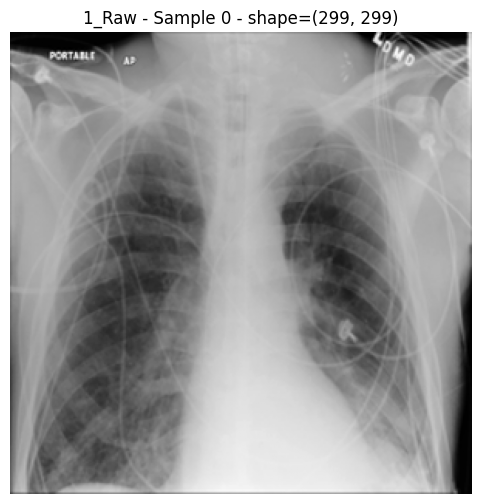

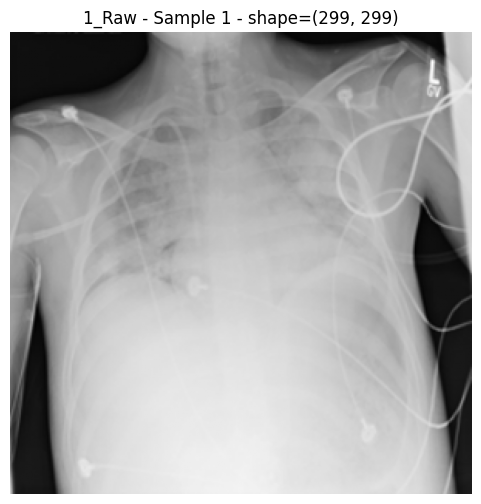

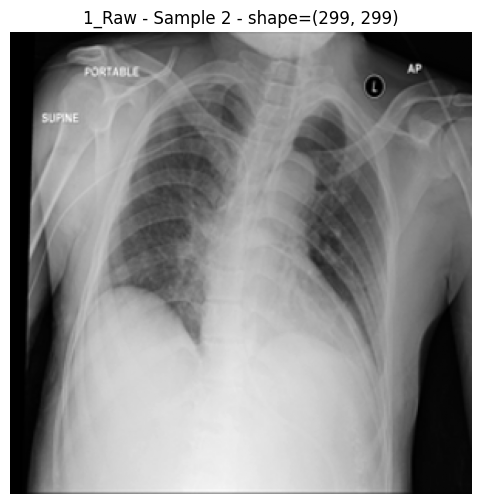

[INFO] [ImageResizer] Redimensionnement de 21165 images en (128, 128) (DataFrame)


[ImageResizer] Redimensionnement: 100%|██████████| 21165/21165 [00:08<00:00, 2488.53it/s]

[INFO] [VisualizeTransformer] Visualisation de 3 échantillons


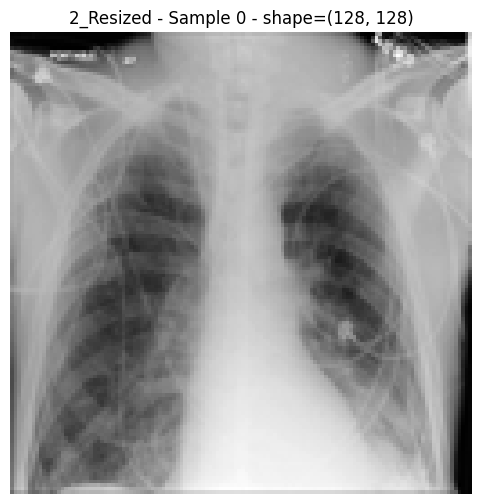

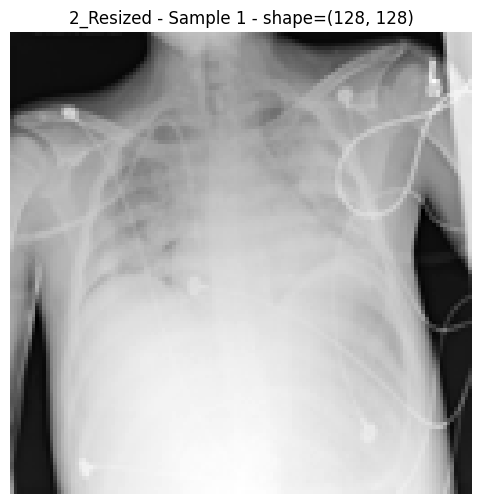

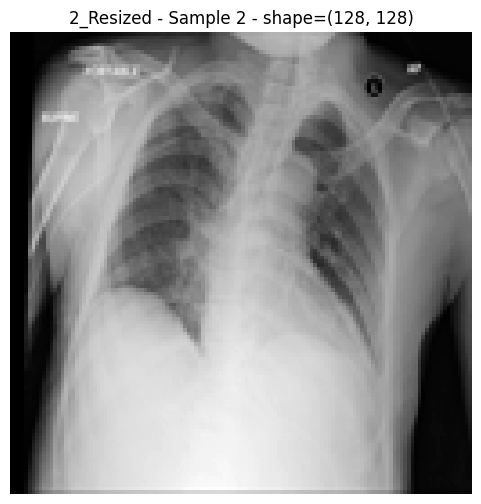

[INFO] [ImageNormalizer] Normalisation de 21165 images (DataFrame)


[ImageNormalizer] Normalisation: 100%|██████████| 21165/21165 [00:02<00:00, 9556.29it/s]



[INFO] [RGB_to_L] Conversion de 21165 images (DataFrame)


[RGB_to_L] RGB → L: 100%|██████████| 21165/21165 [00:00<00:00, 32956.79it/s]

[INFO] [VisualizeTransformer] Visualisation de 3 échantillons


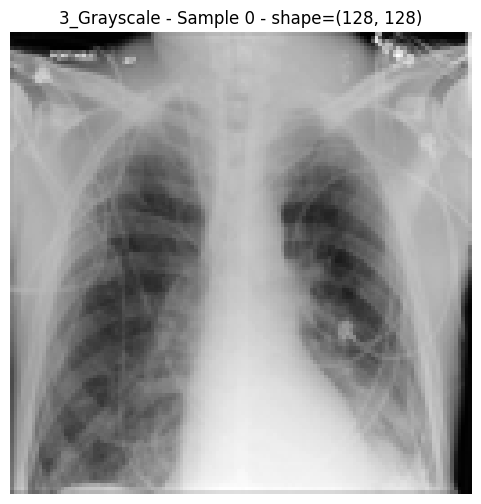

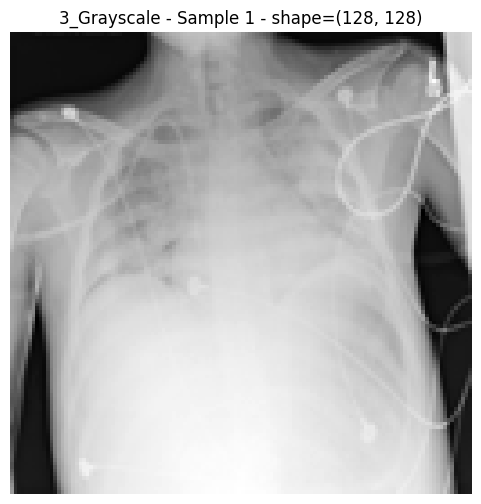

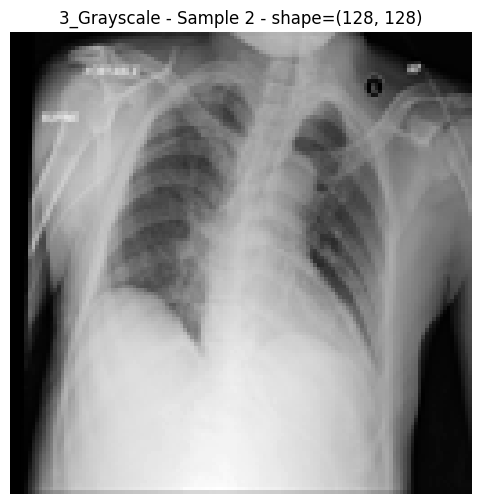


✅ Pipeline preprocessing exécuté!
📊 Shape: (21165, 7)

🔍 Colonnes disponibles:
['image_path', 'mask_path', 'label', 'image_array', 'mean_intensity', 'std_intensity', 'channels']


In [4]:
# Pipeline 2: Preprocessing complet avec chargement d'images
preprocessing_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=True, verbose=True)),  # Charge images en mémoire
    ('visualize_raw', VisualizeTransformer(n_samples=3, prefix="1_Raw")),
    ('resizer', ImageResizer(img_size=(128, 128), verbose=True)),
    ('visualize_resized', VisualizeTransformer(n_samples=3, prefix="2_Resized")),
    ('normalizer', ImageNormalizer(verbose=True)),
    ('gray', RGB_to_L(verbose=True)),
    ('visualize_gray', VisualizeTransformer(n_samples=3, prefix="3_Grayscale")),
])

# Exécution
df_preprocessed = preprocessing_pipeline.fit_transform(None)
print(f"\n✅ Pipeline preprocessing exécuté!")
print(f"📊 Shape: {df_preprocessed.shape}")
print(f"\n🔍 Colonnes disponibles:")
print(df_preprocessed.columns.tolist())

## 6. Pipeline avec Augmentation

[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 31.69it/s]


[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:04<00:00, 4725.73it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 21165 images en mémoire


...

[INFO] [ImageNormalizer] Normalisation de 21165 images (DataFrame)


[ImageNormalizer] Normalisation: 100%|██████████| 21165/21165 [00:02<00:00, 9618.02it/s]



[INFO] [ImageAugmenter] Augmentation de 21165 images (p=0.5) (DataFrame)


[ImageAugmenter] Augmentation: 100%|██████████| 21165/21165 [00:29<00:00, 709.87it/s]



[INFO] [ImageAugmenter] Augmentation terminée: 10665/21165 images augmentées
[INFO] [VisualizeTransformer] Visualisation de 5 échantillons


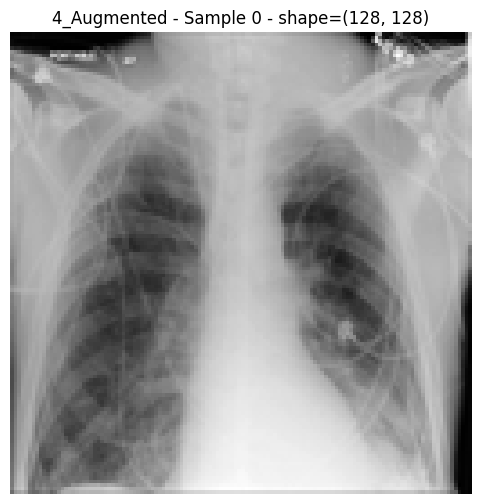

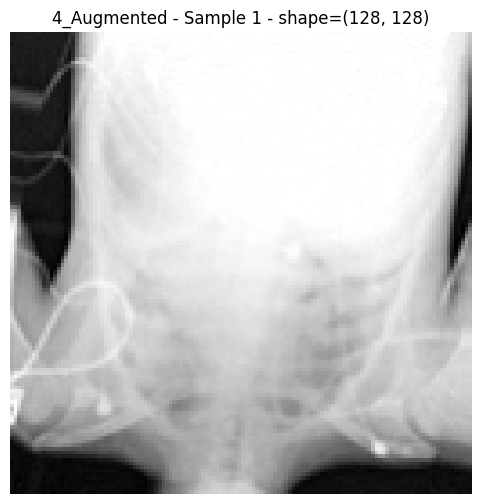

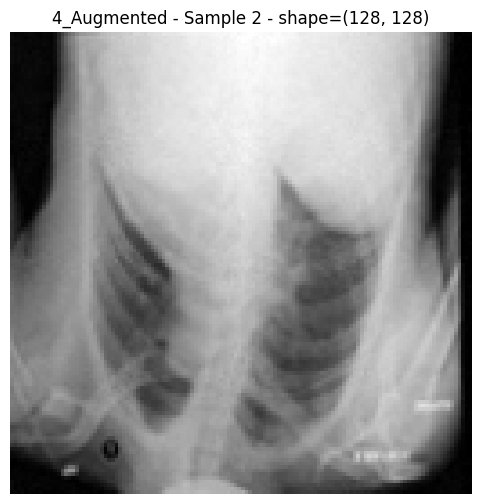

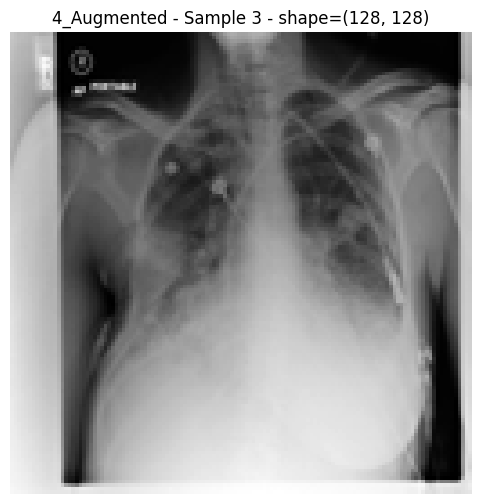

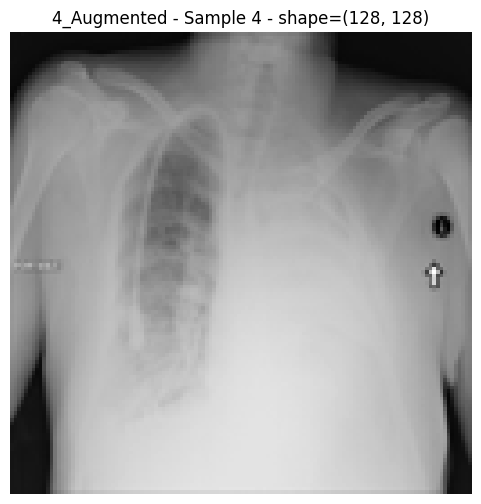


✅ Pipeline augmentation exécuté!
📊 Shape: (21165, 7)


In [5]:
# Pipeline 3: Avec augmentation pour le training set
augmentation_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=True, verbose=True)),
    ('resizer', ImageResizer(img_size=(128, 128), verbose=True)),
    ('normalizer', ImageNormalizer(verbose=True)),
    ('augmenter', ImageAugmenter(
        flip_horizontal=True,
        flip_vertical=True,
        rotation_range=15,
        brightness_range=0.2,
        noise_std=0.01,
        zoom_range=0.1,
        probability=0.5,
        seed=42,
        verbose=True
    )),
    ('visualize_augmented', VisualizeTransformer(n_samples=5, prefix="4_Augmented")),
])

# Exécution
df_augmented = augmentation_pipeline.fit_transform(None)
print(f"\n✅ Pipeline augmentation exécuté!")
print(f"📊 Shape: {df_augmented.shape}")

## 7. Pipeline Feature Extraction - PCA

[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 29.85it/s]


[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:02<00:00, 9856.20it/s] 



[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 21165 images en mémoire


...

[INFO] [RGB_to_L] Conversion de 21165 images (DataFrame)


[RGB_to_L] RGB → L: 100%|██████████| 21165/21165 [00:00<00:00, 33558.87it/s]



[INFO] [ImageFlattener] Aplatissement de 21165 images (DataFrame)


[ImageFlattener] Aplatissement: 100%|██████████| 21165/21165 [00:00<00:00, 28786.85it/s]



[INFO] [ImagePCA] Apprentissage PCA avec 50 composantes sur (21165, 4096)
[INFO] [ImagePCA] PCA fitted. Variance expliquée: 99.67%
[INFO] [ImagePCA] PCA fitted. Variance expliquée: 99.67%
[INFO] [ImagePCA] Application PCA sur (21165, 4096)
[INFO] [ImagePCA] PCA terminé. Shape: (21165, 50)
[INFO] [SaveTransformer] Features sauvegardées dans outputs/features_pca.npy - Shape: (21165, 50)

✅ Pipeline PCA exécuté!
📊 Features extraites: (21165, 50)
[INFO] [ImagePCA] Application PCA sur (21165, 4096)
[INFO] [ImagePCA] PCA terminé. Shape: (21165, 50)
[INFO] [SaveTransformer] Features sauvegardées dans outputs/features_pca.npy - Shape: (21165, 50)

✅ Pipeline PCA exécuté!
📊 Features extraites: (21165, 50)


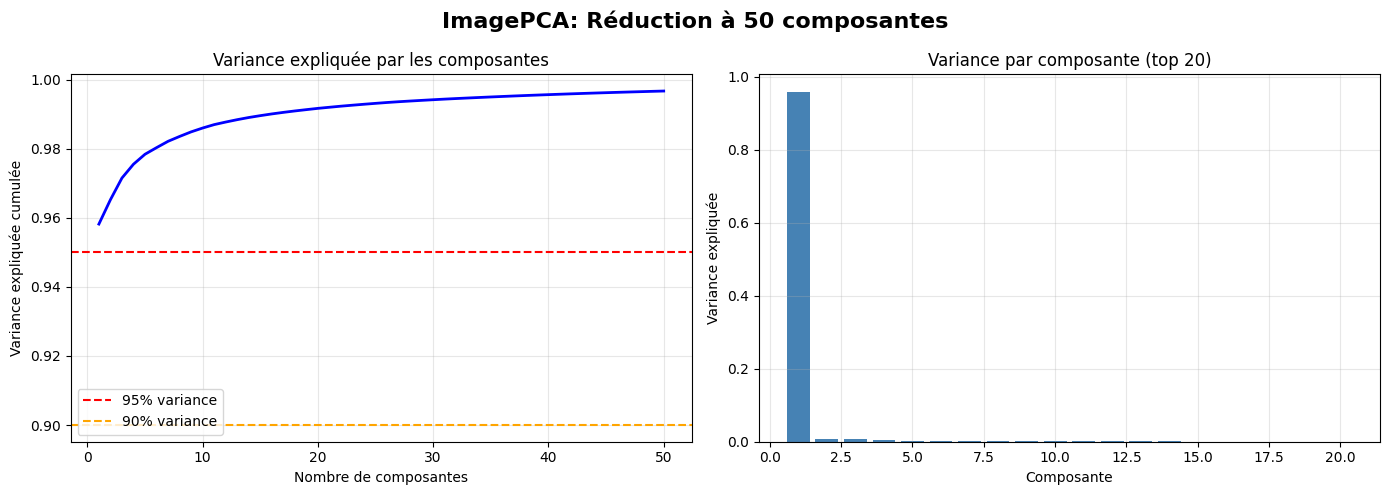


📊 Statistiques PCA:
   - Dimensions avant: N/A
   - Dimensions après: (21165, 50)
   - Variance totale expliquée: 99.67%


In [6]:
# Pipeline 4: Extraction de features avec PCA
pca_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=True, verbose=True)),
    ('resizer', ImageResizer(img_size=(64, 64), verbose=True)),  # Plus petit pour PCA
    ('normalizer', ImageNormalizer(verbose=True)),
    ('gray', RGB_to_L(verbose=True)),
    ('flattener', ImageFlattener(verbose=True)),
    ('pca', ImagePCA(n_components=50, verbose=True)),
    ('saver', SaveTransformer(save_dir='outputs', prefix='features_pca', verbose=True)),
])

# Exécution
X_pca = pca_pipeline.fit_transform(None)
print(f"\n✅ Pipeline PCA exécuté!")
print(f"📊 Features extraites: {X_pca.shape}")

# Visualisation variance expliquée
pca_pipeline.named_steps['pca'].visualize(None, X_pca)

## 8. Pipeline Feature Extraction - Histogrammes

[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 37.71it/s]



[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:02<00:00, 10456.33it/s]



[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 21165 images en mémoire


...

[ImageResizer] Redimensionnement: 100%|██████████| 21165/21165 [00:09<00:00, 2310.59it/s]


[INFO] [ImageNormalizer] Normalisation de 21165 images (DataFrame)


[ImageNormalizer] Normalisation: 100%|██████████| 21165/21165 [00:01<00:00, 10634.99it/s]



[INFO] [RGB_to_L] Conversion de 21165 images (DataFrame)


[RGB_to_L] RGB → L: 100%|██████████| 21165/21165 [00:00<00:00, 32162.44it/s]



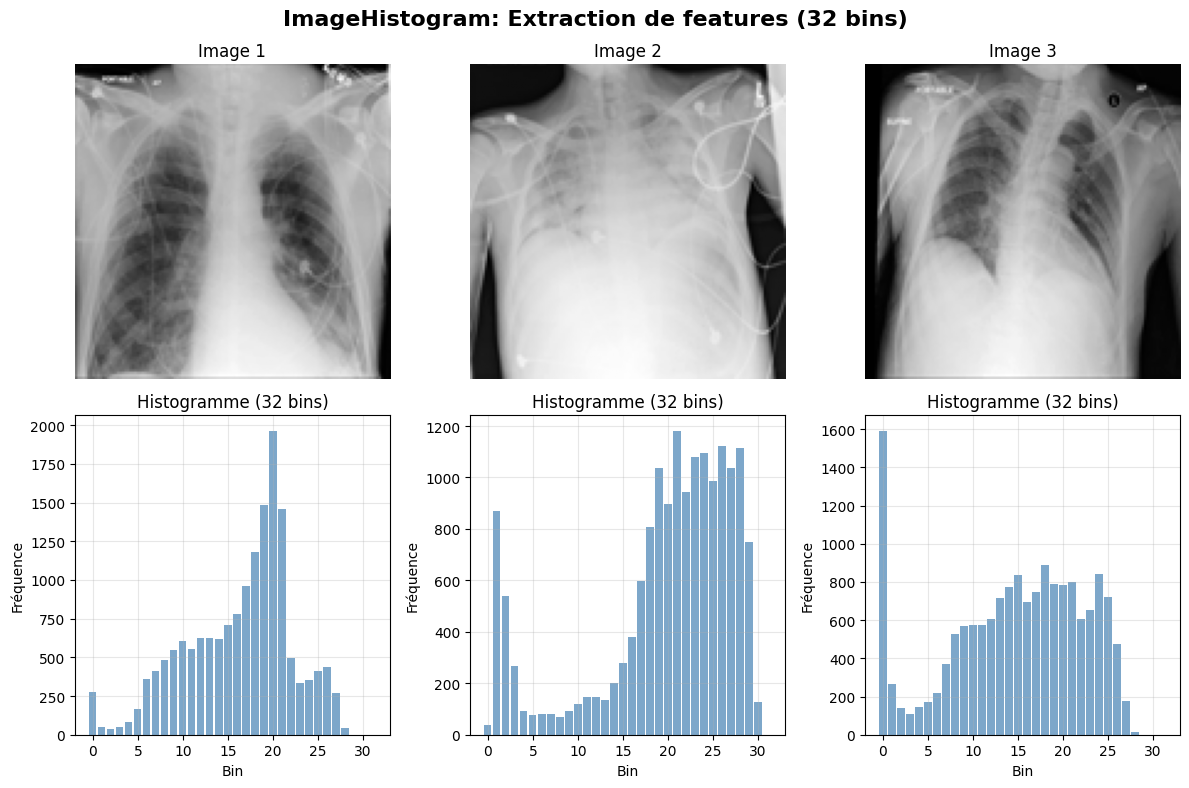


📊 Statistiques histogrammes:
   - Nombre de bins: 32
   - Shape output: (21165, 32)
   - Compression: 16384 pixels → 32 features


In [7]:
# Pipeline 5: Extraction de features avec histogrammes
histogram_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=True, verbose=True)),
    ('resizer', ImageResizer(img_size=(128, 128), verbose=True)),
    ('normalizer', ImageNormalizer(verbose=True)),
    ('gray', RGB_to_L(verbose=True)),
    ('histogram', ImageHistogram(bins=32, verbose=True)),
    ('saver', SaveTransformer(save_dir='outputs', prefix='features_histogram', verbose=True)),
])

# Exécution
X_histogram = histogram_pipeline.fit_transform(None)
print(f"\n✅ Pipeline histogrammes exécuté!")
print(f"📊 Features extraites: {X_histogram.shape}")

# Visualisation des histogrammes
histogram_pipeline.named_steps['histogram'].visualize(
    histogram_pipeline.named_steps['gray'].transform(
        histogram_pipeline.named_steps['normalizer'].transform(
            histogram_pipeline.named_steps['resizer'].transform(
                histogram_pipeline.named_steps['analyzer'].transform(
                    histogram_pipeline.named_steps['tuple_to_df'].transform(
                        histogram_pipeline.named_steps['loader'].transform(None)
                    )
                )
            )
        )
    ),
    X_histogram,
    n_samples=3
)

## 9. Pipeline avec Masking

[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 36.64it/s]



[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:06<00:00, 3132.17it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 21165 images en mémoire


...

[INFO] [ImageNormalizer] Normalisation de 21165 images (DataFrame)


[ImageNormalizer] Normalisation: 100%|██████████| 21165/21165 [00:02<00:00, 8398.62it/s]



[INFO] [ImageMasker] Application des masques sur 21165 images (DataFrame)


[ImageMasker] Masquage: 100%|██████████| 21165/21165 [00:20<00:00, 1043.93it/s]



[INFO] [VisualizeTransformer] Visualisation de 5 échantillons


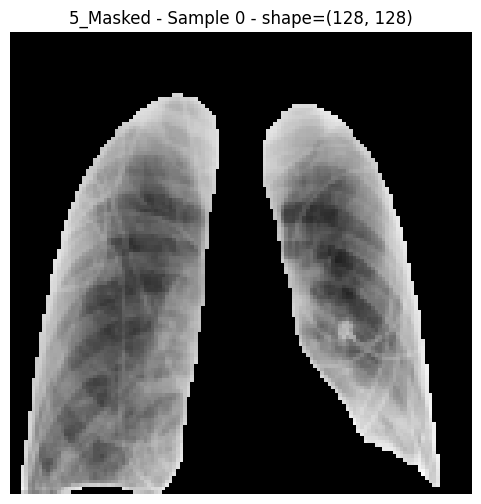

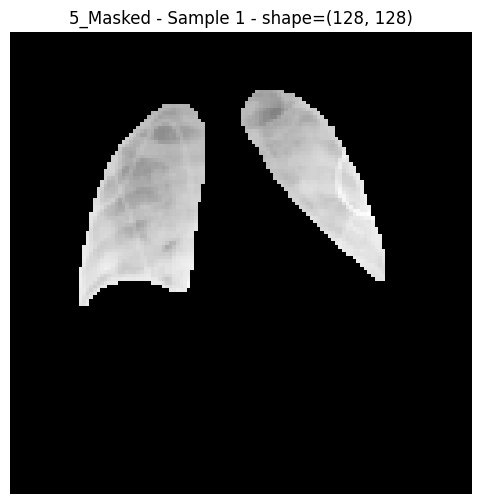

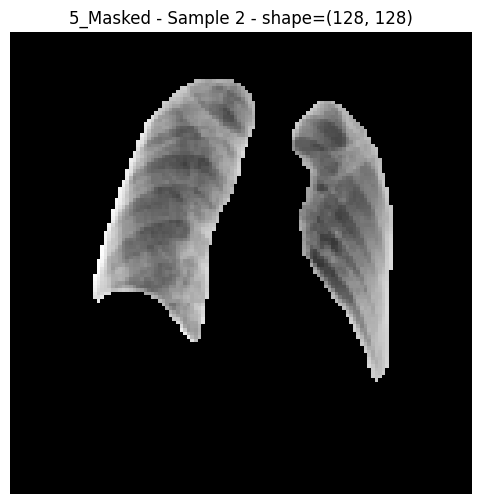

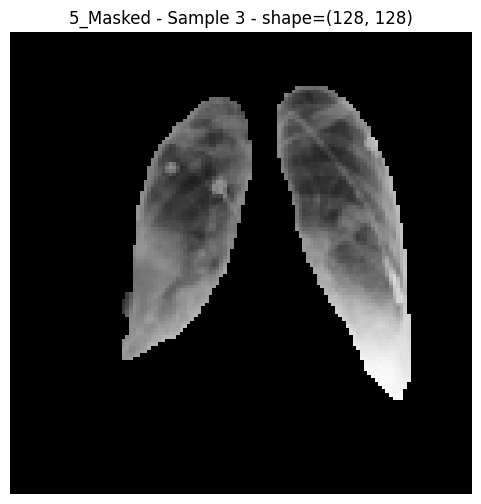

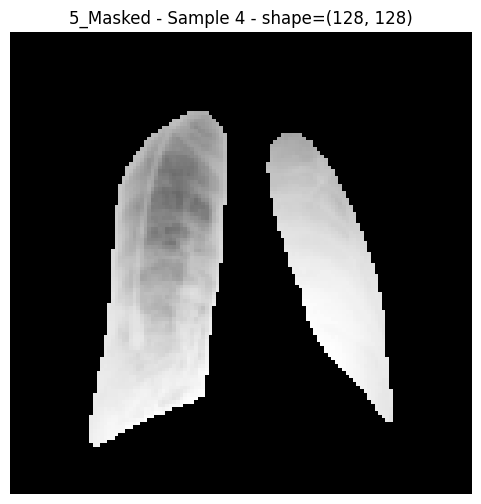

[INFO] [RGB_to_L] Conversion de 21165 images (DataFrame)


[RGB_to_L] RGB → L: 100%|██████████| 21165/21165 [00:02<00:00, 8420.16it/s] 


✅ Pipeline masking exécuté!
📊 Shape: (21165, 8)


In [8]:
# Pipeline 6: Utilisation des masques pour isoler les poumons
masking_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=True, analyze_masks=True, verbose=True)),
    ('resizer', ImageResizer(img_size=(128, 128), verbose=True)),
    ('normalizer', ImageNormalizer(verbose=True)),
    ('masker', ImageMasker(verbose=True)),  # Applique les masques
    ('visualize_masked', VisualizeTransformer(n_samples=5, prefix="5_Masked")),
    ('gray', RGB_to_L(verbose=True)),
])

# Exécution
df_masked = masking_pipeline.fit_transform(None)
print(f"\n✅ Pipeline masking exécuté!")
print(f"📊 Shape: {df_masked.shape}")

## 10. Notes sur l'utilisation

### 🎯 Bonnes pratiques:

1. **Ordre des transformateurs**: Suivre la logique du pipeline
   - Chargement → Analyse → Preprocessing → Features → ML

2. **Paramètre `verbose`**: Activer pour voir la progression
   ```python
   transformer = ImageResizer(img_size=(128, 128), verbose=True)
   ```

3. **Visualisation**: Utiliser `VisualizeTransformer` entre les étapes pour débugger
   ```python
   Pipeline([
       ('step1', Transformer1()),
       ('viz1', VisualizeTransformer(n_samples=3, prefix="After_Step1")),
       ('step2', Transformer2()),
   ])
   ```

4. **Sauvegarde**: Utiliser `SaveTransformer` pour checkpointer les features
   ```python
   Pipeline([
       ('features', FeatureExtractor()),
       ('save', SaveTransformer(save_dir='outputs', prefix='my_features')),
       ('model', MLModel()),  # Continue le pipeline après sauvegarde
   ])
   ```

5. **Train/Test split**: Fit sur train uniquement pour les transformateurs stateful
   ```python
   # Transformateurs stateful: ImagePCA, ImageStandardScaler
   pca = ImagePCA(n_components=50)
   pca.fit(X_train)
   X_train_pca = pca.transform(X_train)
   X_test_pca = pca.transform(X_test)  # Utilise les composantes apprises
   ```

### 📚 Compatibilité sklearn:

Tous les transformateurs sont compatibles avec:
- `sklearn.pipeline.Pipeline`
- `sklearn.model_selection.GridSearchCV`
- `sklearn.model_selection.cross_val_score`

Exemple:
```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('pca', ImagePCA()),
    ('classifier', RandomForestClassifier()),
])

param_grid = {
    'pca__n_components': [20, 50, 100],
    'classifier__n_estimators': [100, 200],
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=5)
grid_search.fit(X_train, y_train)
```

## 11. Train/Test/Validation Split

[INFO] [TrainTestSplitter] Split train/test: 80%/20%
[INFO] [TrainTestSplitter] ✅ Train: 16932 | Test: 4233

📊 Distribution des labels:

Train:
  - covid: 2893 (17.1%)
  - lung_opacity: 4809 (28.4%)
  - normal: 8154 (48.2%)
  - viral pneumonia: 1076 (6.4%)

Test:
  - covid: 723 (17.1%)
  - lung_opacity: 1203 (28.4%)
  - normal: 2038 (48.1%)
  - viral pneumonia: 269 (6.4%)


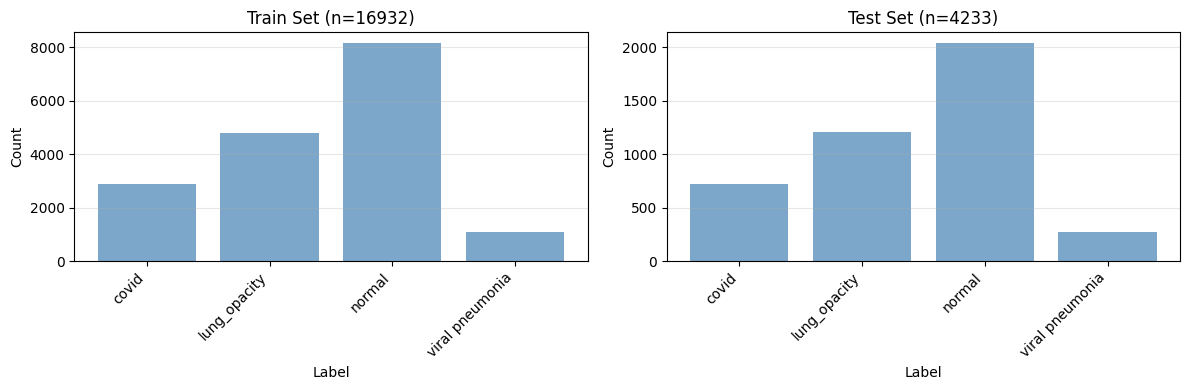


📊 Résumé:
Train: 16932 images
Test: 4233 images


In [9]:
# Exemple 1: Split simple Train/Test (80%/20%)
splitter = TrainTestSplitter(
    test_size=0.2,
    random_state=42,
    stratify=True,
    label_column='label',
    verbose=True
)

# Utiliser le résultat du pipeline de métadonnées
splits = splitter.fit_transform(df_metadata)

# Extraire les splits
X_train, y_train = splits['train']
X_test, y_test = splits['test']

print(f"\n📊 Résumé:")
print(f"Train: {len(X_train)} images")
print(f"Test: {len(X_test)} images")

[INFO] [TrainTestSplitter] Split train/val/test: 70%/15%/15%
[INFO] [TrainTestSplitter] ✅ Train: 14815 | Val: 3175 | Test: 3175

📊 Distribution des labels:

Train:
  - covid: 2532 (17.1%)
  - lung_opacity: 4208 (28.4%)
  - normal: 7134 (48.2%)
  - viral pneumonia: 941 (6.4%)

Val:
  - covid: 542 (17.1%)
  - lung_opacity: 902 (28.4%)
  - normal: 1529 (48.2%)
  - viral pneumonia: 202 (6.4%)

Test:
  - covid: 542 (17.1%)
  - lung_opacity: 902 (28.4%)
  - normal: 1529 (48.2%)
  - viral pneumonia: 202 (6.4%)


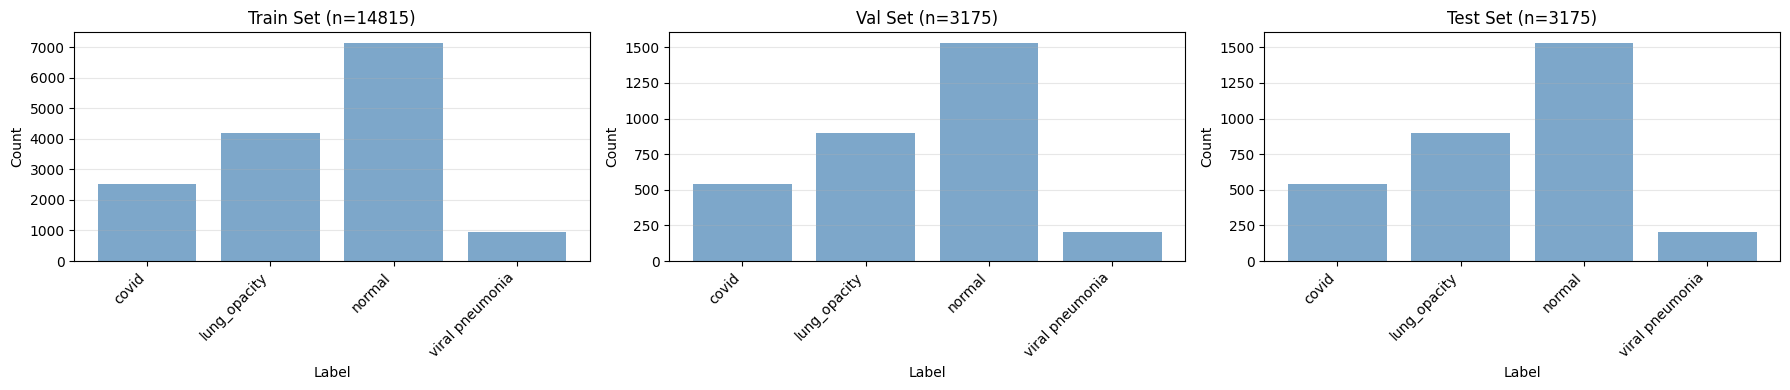


📊 Résumé:
Train: 14815 images
Validation: 3175 images
Test: 3175 images


In [10]:
# Exemple 2: Split Train/Validation/Test (70%/15%/15%)
splitter_3way = TrainTestSplitter(
    test_size=0.15,
    val_size=0.15,
    random_state=42,
    stratify=True,
    label_column='label',
    verbose=True
)

splits_3way = splitter_3way.fit_transform(df_metadata)

# Extraire les 3 splits
X_train, y_train = splits_3way['train']
X_val, y_val = splits_3way['val']
X_test, y_test = splits_3way['test']

print(f"\n📊 Résumé:")
print(f"Train: {len(X_train)} images")
print(f"Validation: {len(X_val)} images")
print(f"Test: {len(X_test)} images")

## 12. Pipeline Complet avec Train/Test Split

[INFO] [ImagePathLoader] Chargement des chemins depuis /home/lena/DS_Covid/DS_COVID/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
[INFO] [ImagePathLoader] Labels trouvés : ['Lung_Opacity', 'Normal', 'COVID', 'Viral Pneumonia']


[ImagePathLoader] Scan labels: 100%|██████████| 4/4 [00:00<00:00, 36.90it/s]

[INFO] [ImagePathLoader] Total chargé : 21165 images
[INFO] [ImagePathLoader] Retour de 21165 chemins
[INFO] [TupleToDataFrame] Conversion de 21165 éléments en DataFrame
[INFO] [TupleToDataFrame] DataFrame créé: 21165 lignes, 3 colonnes
[INFO] [ImageAnalyser] Analyse de 21165 images



[ImageAnalyser] Analyse métadonnées: 100%|██████████| 21165/21165 [00:02<00:00, 9936.34it/s] 



[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement désactivé, retour du DataFrame original
[INFO] [TrainTestSplitter] Split train/test: 80%/20%
[INFO] [TrainTestSplitter] ✅ Train: 16932 | Test: 4233

📊 Distribution des labels:

Train:
  - covid: 2893 (17.1%)
  - lung_opacity: 4809 (28.4%)
  - normal: 8154 (48.2%)
  - viral pneumonia: 1076 (6.4%)

Test:
  - covid: 723 (17.1%)
  - lung_opacity: 1203 (28.4%)
  - normal: 2038 (48.1%)
  - viral pneumonia: 269 (6.4%)


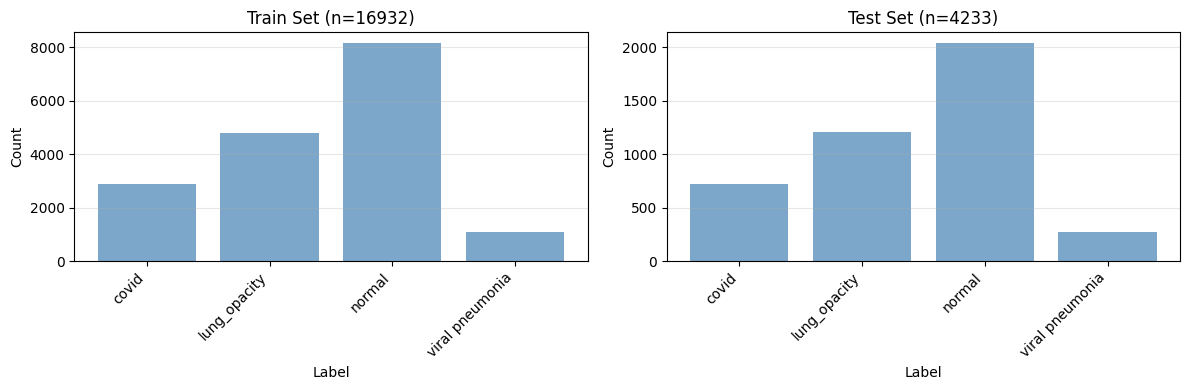


✅ Splits créés! Maintenant preprocessing des images...

🔹 Extraction features TRAIN...
[INFO] [ImageAnalyser] Analyse de 16932 images


[ImageAnalyser] Analyse métadonnées: 100%|██████████| 16932/16932 [00:01<00:00, 9293.98it/s]


[INFO] [ImageAnalyser] Analyse terminée: 1 dimensions uniques
[INFO] [ImageAnalyser] Chargement de 16932 images en mémoire


[ImageAnalyser] Chargement images:  29%|██▉       | 4990/16932 [00:07<00:16, 713.44it/s]

In [ ]:
# Pipeline complet: Preprocessing + Split + Feature Extraction
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Pipeline de preprocessing (métadonnées seulement pour le split)
metadata_pipeline = Pipeline([
    ('loader', ImagePathLoader(root_dir=ROOT_DIR, verbose=True)),
    ('tuple_to_df', TupleToDataFrame(verbose=True)),
    ('analyzer', ImageAnalyser(load_images=False, verbose=True)),
    ('splitter', TrainTestSplitter(test_size=0.2, random_state=42, verbose=True)),
])

# Créer les splits
splits = metadata_pipeline.fit_transform(None)
X_train_meta, y_train = splits['train']
X_test_meta, y_test = splits['test']

print("\n" + "="*60)
print("✅ Splits créés! Maintenant preprocessing des images...")
print("="*60)

# 2. Pipeline de feature extraction (à appliquer sur train et test séparément)
feature_pipeline = Pipeline([
    ('analyzer', ImageAnalyser(load_images=True, verbose=True)),
    ('resizer', ImageResizer(img_size=(64, 64), verbose=True)),
    ('normalizer', ImageNormalizer(verbose=True)),
    ('gray', RGB_to_L(verbose=True)),
    ('flattener', ImageFlattener(verbose=True)),
])

# Fit sur train, transform sur train et test
print("\n🔹 Extraction features TRAIN...")
X_train_features = feature_pipeline.fit_transform(X_train_meta)

print("\n🔹 Extraction features TEST...")
X_test_features = feature_pipeline.transform(X_test_meta)

print(f"\n📊 Features extraites:")
print(f"   Train: {X_train_features.shape}")
print(f"   Test: {X_test_features.shape}")

# 3. Entraîner un modèle ML
print("\n" + "="*60)
print("🤖 Entraînement du modèle RandomForest...")
print("="*60)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=1)
clf.fit(X_train_features, y_train)

# 4. Évaluation
print("\n📈 Évaluation sur le test set:")
y_pred = clf.predict(X_test_features)
print("\n" + classification_report(y_test, y_pred))

# Matrice de confusion
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

print(f"\n✅ Pipeline complet exécuté avec succès!")
print(f"   Accuracy: {clf.score(X_test_features, y_test):.2%}")